In [1]:
import sys
import time
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import pymc as pm
import arviz as az

warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\Alejandro\anaconda3\envs\policeproj\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
def find_project_root(start: Path) -> Path:
    """Walk upward from `start` until we find src/cbl20."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "cbl20").exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root containing src/cbl20 from: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Detected src dir:", SRC_DIR)
print("cbl20 exists:", (SRC_DIR / "cbl20").exists())
print("spatial_adjacency exists:", (SRC_DIR / "cbl20" / "spatial_adjacency.py").exists())

from cbl20.spatial_adjacency import (
    load_lsoa_centroids,
    validate_lsoa_code_coverage,
    build_knn_adjacency_from_centroids,
    summarize_adjacency,
    add_neighbour_previous_month_feature,
    save_adjacency,
)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPATIAL_DIR = DATA_DIR / "spatial"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CRIME_PARQUET_PATH = PROCESSED_DIR / "crimes_filtered_for_model.parquet"
if not CRIME_PARQUET_PATH.exists():
    CRIME_PARQUET_PATH = PROCESSED_DIR / "crimes_clean_dedup_all_years.parquet"

LSOA_CENTROID_CSV = (
    SPATIAL_DIR
    / "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_4163309575471683775.csv"
)

POPULATION_PARQUET_PATH = PROCESSED_DIR / "lsoa_population_yearly.parquet"

print("Crime parquet:", CRIME_PARQUET_PATH)
print("Crime parquet exists:", CRIME_PARQUET_PATH.exists())
print("LSOA centroid CSV:", LSOA_CENTROID_CSV)
print("LSOA centroid CSV exists:", LSOA_CENTROID_CSV.exists())
print("Population parquet:", POPULATION_PARQUET_PATH)
print("Population parquet exists:", POPULATION_PARQUET_PATH.exists())


Working directory: c:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\notebooks
Detected project root: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20
Detected src dir: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\src
cbl20 exists: True
spatial_adjacency exists: True
Crime parquet: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\data\processed\crimes_filtered_for_model.parquet
Crime parquet exists: True
LSOA centroid CSV: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\data\spatial\Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_4163309575471683775.csv
LSOA centroid CSV exists: True
Population parquet: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\data\processed\lsoa_population_yearly.parquet
Population parquet exists: True


In [3]:
# Config
RUN_ALL_TERRITORIAL_POLICE_FORCES = True

POLICE_FORCES_TO_RUN = [
    "West Midlands Police",
]

# British Transport Police is not territorial. City of London is, so we keep it.
EXCLUDED_POLICE_FORCES = {
    "British Transport Police",
}

CRIME_TYPES_TO_RUN = "all"

# Set to None for a full run.
MAX_FORCES_TO_RUN = 5
MAX_CRIME_TYPES_PER_FORCE = 5

START_MONTH = "2017-01"
END_MONTH = "2019-12"
TRAIN_END_MONTH = "2018-12"
TEST_START_MONTH = "2019-01"
TEST_END_MONTH = "2019-12"

MAX_LSOAS_PER_MODEL = 100
MIN_TOTAL_CRIMES_PER_LSOA = 1

USE_ADJACENCY = True
ADJACENCY_K_NEIGHBOURS = 5
MIN_CENTROID_COVERAGE = 0.80

# Offset off by default - didn't help in earlier tests.
USE_POPULATION_OFFSET = False
ALLOW_LATEST_POPULATION_YEAR_FALLBACK = True

# Bump draws/tune to 500-1000 for final diagnostics.
DRAWS = 300
TUNE = 300
CHAINS = 2
TARGET_ACCEPT = 0.9
RANDOM_SEED = 42

SAVE_PER_RUN_FILES = True

MODEL_TAG = (
    "all_forces_adjacency"
    + ("_population_offset" if USE_POPULATION_OFFSET else "_no_offset")
)

print("Model tag:", MODEL_TAG)
print("Run all territorial forces:", RUN_ALL_TERRITORIAL_POLICE_FORCES)
print("Use adjacency:", USE_ADJACENCY)
print("Use population offset:", USE_POPULATION_OFFSET)


Model tag: all_forces_adjacency_no_offset
Run all territorial forces: True
Use adjacency: True
Use population offset: False


In [4]:
lsoa_centroids = load_lsoa_centroids(LSOA_CENTROID_CSV)

if USE_POPULATION_OFFSET:
    if not POPULATION_PARQUET_PATH.exists():
        raise FileNotFoundError(
            f"Population parquet not found at {POPULATION_PARQUET_PATH}. "
            "Run: python -m src.cbl20.population_offset"
        )

    population_yearly = pd.read_parquet(POPULATION_PARQUET_PATH)
    population_yearly["lsoa_code"] = population_yearly["lsoa_code"].astype(str).str.strip()
    population_yearly["population_year"] = population_yearly["population_year"].astype(int)
    population_yearly["population"] = pd.to_numeric(population_yearly["population"], errors="coerce")

    if population_yearly["population"].isna().any():
        raise ValueError("Population parquet contains missing/non-numeric population values.")
    if (population_yearly["population"] <= 0).any():
        raise ValueError("Population parquet contains non-positive population values.")

    latest_population_year = int(population_yearly["population_year"].max())
    earliest_population_year = int(population_yearly["population_year"].min())

    print("Population years:", earliest_population_year, "to", latest_population_year)
    print("Population rows:", len(population_yearly))
    print("Population LSOAs:", population_yearly["lsoa_code"].nunique())
else:
    population_yearly = None
    print("Population offset disabled. log_offset will be set to 0.0.")

print("Centroid LSOAs:", lsoa_centroids["lsoa_code"].nunique())


Population offset disabled. log_offset will be set to 0.0.
Centroid LSOAs: 35672


In [5]:
def list_available_crime_types_for_scope(
    parquet_path: Path,
    police_force: str,
    start_month: str,
    end_month: str,
) -> pd.DataFrame:
    return duckdb.sql(f"""
        SELECT
            "Crime type" AS crime_type,
            COUNT(*) AS n_records
        FROM read_parquet('{parquet_path.as_posix()}')
        WHERE "Falls within" = '{police_force}'
          AND "Crime type" IS NOT NULL
          AND "Month" BETWEEN '{start_month}' AND '{end_month}'
        GROUP BY "Crime type"
        ORDER BY n_records DESC
    """).df()


def list_available_police_forces_for_scope(
    parquet_path: Path,
    start_month: str,
    end_month: str,
    excluded_forces: set[str] | None = None,
) -> pd.DataFrame:
    excluded_forces = excluded_forces or set()
    forces = duckdb.sql(f"""
        SELECT
            "Falls within" AS police_force,
            COUNT(*) AS n_records,
            COUNT(DISTINCT "LSOA code") AS n_lsoas
        FROM read_parquet('{parquet_path.as_posix()}')
        WHERE "Falls within" IS NOT NULL
          AND "Month" BETWEEN '{start_month}' AND '{end_month}'
        GROUP BY "Falls within"
        ORDER BY n_records DESC
    """).df()

    if excluded_forces:
        forces = forces[~forces["police_force"].isin(excluded_forces)].copy()

    return forces.reset_index(drop=True)


available_forces_scope = list_available_police_forces_for_scope(
    CRIME_PARQUET_PATH,
    START_MONTH,
    END_MONTH,
    EXCLUDED_POLICE_FORCES,
)

available_forces_scope.head(20)


,police_force,n_records,n_lsoas
0,Metropolitan Police Service,2163826,7504
1,Greater Manchester Police,734517,1697
2,West Yorkshire Police,710153,1458
3,West Midlands Police,651165,1940
4,Kent Police,441027,1482
5,Northumbria Police,433115,940
6,Lancashire Constabulary,421450,1589
7,Essex Police,419692,1914
8,Hampshire Constabulary,402494,1542
9,South Yorkshire Police,399707,1131


In [6]:
def get_police_forces_to_run() -> list[str]:
    if RUN_ALL_TERRITORIAL_POLICE_FORCES:
        forces = available_forces_scope["police_force"].tolist()
    else:
        forces = POLICE_FORCES_TO_RUN

    if MAX_FORCES_TO_RUN is not None:
        forces = forces[:MAX_FORCES_TO_RUN]

    return forces


def get_crime_types_to_run(police_force: str) -> list[str]:
    crimes = list_available_crime_types_for_scope(
        CRIME_PARQUET_PATH,
        police_force,
        START_MONTH,
        END_MONTH,
    )
    if CRIME_TYPES_TO_RUN == "all":
        crime_list = crimes["crime_type"].tolist()
    else:
        crime_list = [c for c in CRIME_TYPES_TO_RUN if c in set(crimes["crime_type"])]

    if MAX_CRIME_TYPES_PER_FORCE is not None:
        crime_list = crime_list[:MAX_CRIME_TYPES_PER_FORCE]

    return crime_list


police_forces_to_run = get_police_forces_to_run()

model_runs = []
for force in police_forces_to_run:
    for crime_type in get_crime_types_to_run(force):
        model_runs.append({"police_force": force, "crime_type": crime_type})

print("Forces to run:", len(police_forces_to_run))
print("Model runs:", len(model_runs))
pd.DataFrame(model_runs).head(30)


Forces to run: 5
Model runs: 25


,police_force,crime_type
0,Metropolitan Police Service,Violence and sexual offences
1,Metropolitan Police Service,Anti-social behaviour
2,Metropolitan Police Service,Vehicle crime
3,Metropolitan Police Service,Other theft
4,Metropolitan Police Service,Burglary
5,Greater Manchester Police,Violence and sexual offences
6,Greater Manchester Police,Anti-social behaviour
7,Greater Manchester Police,Public order
8,Greater Manchester Police,Criminal damage and arson
9,Greater Manchester Police,Burglary


In [7]:
def build_lsoa_month_panel(
    parquet_path: Path,
    police_force: str,
    crime_type: str,
    start_month: str,
    end_month: str,
    lsoa_reference: pd.DataFrame,
    max_lsoas: int | None = 100,
    min_total_crimes: int = 1,
    min_centroid_coverage: float = 0.80,
) -> tuple[pd.DataFrame, dict]:
    """Build a complete LSOA-month panel for one force and crime type."""
    parquet_path = Path(parquet_path).as_posix()

    lsoas = duckdb.sql(f"""
        SELECT
            "LSOA code" AS lsoa_code,
            ANY_VALUE("LSOA name") AS lsoa_name
        FROM read_parquet('{parquet_path}')
        WHERE "LSOA code" IS NOT NULL
          AND "Falls within" = '{police_force}'
          AND "Month" BETWEEN '{start_month}' AND '{end_month}'
        GROUP BY "LSOA code"
    """).df()

    if lsoas.empty:
        raise ValueError(f"No LSOAs found for {police_force} between {start_month} and {end_month}.")

    counts = duckdb.sql(f"""
        SELECT
            "LSOA code" AS lsoa_code,
            "Month" AS month,
            COUNT(*) AS crime_count
        FROM read_parquet('{parquet_path}')
        WHERE "LSOA code" IS NOT NULL
          AND "Falls within" = '{police_force}'
          AND "Crime type" = '{crime_type}'
          AND "Month" BETWEEN '{start_month}' AND '{end_month}'
        GROUP BY "LSOA code", "Month"
    """).df()

    if counts.empty:
        raise ValueError(f"No rows found for {police_force} | {crime_type} in selected period.")

    counts["month"] = pd.to_datetime(counts["month"], format="%Y-%m")
    counts["lsoa_code"] = counts["lsoa_code"].astype(str).str.strip()
    lsoas["lsoa_code"] = lsoas["lsoa_code"].astype(str).str.strip()

    totals = (
        counts.groupby("lsoa_code", as_index=False)["crime_count"]
        .sum()
        .rename(columns={"crime_count": "total_selected_crimes"})
    )

    lsoas = lsoas.merge(totals, on="lsoa_code", how="left")
    lsoas["total_selected_crimes"] = lsoas["total_selected_crimes"].fillna(0)
    lsoas = lsoas[lsoas["total_selected_crimes"] >= min_total_crimes].copy()

    if lsoas.empty:
        raise ValueError(
            f"No LSOAs had at least {min_total_crimes} {crime_type!r} crimes in selected period."
        )

    coverage = validate_lsoa_code_coverage(lsoas["lsoa_code"], lsoa_reference)
    if coverage["coverage_rate"] < min_centroid_coverage:
        raise ValueError(
            "Low LSOA centroid coverage for adjacency. "
            f"Coverage={coverage['coverage_rate']:.3f}; "
            f"matched={coverage['n_matched_lsoas']}; missing={coverage['n_missing_lsoas']}; "
            f"sample_missing={coverage['missing_lsoas_sample']}"
        )

    centroid_codes = set(lsoa_reference["lsoa_code"].astype(str))
    n_before = lsoas["lsoa_code"].nunique()
    lsoas = lsoas[lsoas["lsoa_code"].isin(centroid_codes)].copy()
    n_after = lsoas["lsoa_code"].nunique()

    lsoas = lsoas.sort_values("total_selected_crimes", ascending=False)
    if max_lsoas is not None:
        lsoas = lsoas.head(max_lsoas)

    if lsoas.empty:
        raise ValueError("No matched LSOAs remain after centroid filtering.")

    months = pd.date_range(
        start=pd.to_datetime(start_month, format="%Y-%m"),
        end=pd.to_datetime(end_month, format="%Y-%m"),
        freq="MS",
    )

    panel_index = pd.MultiIndex.from_product(
        [lsoas["lsoa_code"], months],
        names=["lsoa_code", "month"],
    )

    panel = panel_index.to_frame(index=False)
    panel = panel.merge(lsoas[["lsoa_code", "lsoa_name"]], on="lsoa_code", how="left")
    panel = panel.merge(counts, on=["lsoa_code", "month"], how="left")

    panel["crime_count"] = panel["crime_count"].fillna(0).astype(int)
    panel["police_force"] = police_force
    panel["crime_type"] = crime_type
    panel["month_num"] = panel["month"].dt.month
    panel["month_id"] = panel["month_num"] - 1

    min_month = panel["month"].min()
    panel["time_index"] = (
        (panel["month"].dt.year - min_month.year) * 12
        + (panel["month"].dt.month - min_month.month)
    )
    std = panel["time_index"].std()
    panel["time_scaled"] = 0.0 if std == 0 or np.isnan(std) else (
        panel["time_index"] - panel["time_index"].mean()
    ) / std

    panel["lsoa_id"] = pd.Categorical(panel["lsoa_code"]).codes
    panel["log_offset"] = 0.0

    metadata = {
        "n_lsoas_before_centroid_filter": int(n_before),
        "n_lsoas_after_centroid_filter": int(n_after),
        "n_lsoas_dropped_no_centroid": int(n_before - n_after),
        "centroid_coverage": float(coverage["coverage_rate"]),
        "missing_lsoas_sample": coverage["missing_lsoas_sample"],
    }

    return panel.sort_values(["lsoa_code", "month"]).reset_index(drop=True), metadata


In [8]:
def add_population_offset_to_panel(
    panel: pd.DataFrame,
    population_df: pd.DataFrame,
    allow_latest_year_fallback: bool = True,
) -> tuple[pd.DataFrame, dict]:
    """Join yearly LSOA population estimates onto the panel and build log_offset."""
    out = panel.copy()
    pop = population_df.copy()

    pop["lsoa_code"] = pop["lsoa_code"].astype(str).str.strip()
    pop["population_year"] = pop["population_year"].astype(int)
    pop["population"] = pd.to_numeric(pop["population"], errors="coerce")

    latest_year = int(pop["population_year"].max())
    earliest_year = int(pop["population_year"].min())

    out["population_year_requested"] = out["month"].dt.year.astype(int)

    if allow_latest_year_fallback:
        out["population_year_used"] = out["population_year_requested"].clip(
            lower=earliest_year,
            upper=latest_year,
        )
    else:
        out["population_year_used"] = out["population_year_requested"]

    out = out.merge(
        pop[["lsoa_code", "population_year", "population"]],
        left_on=["lsoa_code", "population_year_used"],
        right_on=["lsoa_code", "population_year"],
        how="left",
    )

    missing_rows = int(out["population"].isna().sum())
    missing_rate = float(out["population"].isna().mean())

    if missing_rate > 0.05:
        missing_codes = (
            out.loc[out["population"].isna(), "lsoa_code"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()[:20]
        )
        raise ValueError(
            f"Too many panel rows missing population after join: {missing_rate:.2%}. "
            f"Sample missing LSOAs: {missing_codes}"
        )

    # Should be rare after centroid filtering.
    median_pop = float(out["population"].median())
    out["population"] = out["population"].fillna(median_pop)

    if (out["population"] <= 0).any():
        raise ValueError("Population values must be positive before log offset.")

    out["log_population_offset"] = np.log(out["population"])
    out["log_offset"] = out["log_population_offset"]

    metadata = {
        "population_earliest_year": earliest_year,
        "population_latest_year": latest_year,
        "population_missing_rows": missing_rows,
        "population_missing_rate": missing_rate,
        "population_min": float(out["population"].min()),
        "population_max": float(out["population"].max()),
        "population_median": median_pop,
        "uses_latest_population_year_fallback": bool(allow_latest_year_fallback),
    }

    return out, metadata


def apply_offset_mode(df: pd.DataFrame, use_population_offset: bool) -> pd.DataFrame:
    out = df.copy()
    if use_population_offset:
        if "log_population_offset" not in out.columns:
            raise ValueError("log_population_offset is missing. Run add_population_offset_to_panel() first.")
        out["log_offset"] = out["log_population_offset"]
    else:
        out["log_offset"] = 0.0
    return out


def add_adjacency_features_to_panel(
    panel: pd.DataFrame,
    lsoa_reference: pd.DataFrame,
    k_neighbours: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    lsoa_codes = sorted(panel["lsoa_code"].dropna().astype(str).unique())

    adjacency = build_knn_adjacency_from_centroids(
        lsoa_reference,
        lsoa_codes=lsoa_codes,
        k=k_neighbours,
    )

    adjacency_summary = summarize_adjacency(adjacency)

    panel_adj = add_neighbour_previous_month_feature(
        panel,
        adjacency,
        output_col="neighbour_prev_month_count",
        scale_output=False,
    )

    return panel_adj, adjacency, adjacency_summary


def chronological_train_test_split(
    panel: pd.DataFrame,
    train_end_month: str,
    test_start_month: str,
    test_end_month: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_end = pd.to_datetime(train_end_month, format="%Y-%m")
    test_start = pd.to_datetime(test_start_month, format="%Y-%m")
    test_end = pd.to_datetime(test_end_month, format="%Y-%m")

    train = panel[panel["month"] <= train_end].copy()
    test = panel[(panel["month"] >= test_start) & (panel["month"] <= test_end)].copy()

    if train.empty:
        raise ValueError("Training set is empty.")
    if test.empty:
        raise ValueError("Test set is empty.")

    categories = pd.Categorical(train["lsoa_code"]).categories
    train["lsoa_id"] = pd.Categorical(train["lsoa_code"], categories=categories).codes
    test["lsoa_id"] = pd.Categorical(test["lsoa_code"], categories=categories).codes
    test = test[test["lsoa_id"] >= 0].copy()

    return train.reset_index(drop=True), test.reset_index(drop=True)


def scale_spatial_lag_using_train(
    train: pd.DataFrame,
    test: pd.DataFrame,
    source_col: str = "neighbour_prev_month_count",
    scaled_col: str = "neighbour_prev_month_scaled",
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """Scale spatial lag using train mean/std only - avoids leakage."""
    train = train.copy()
    test = test.copy()

    mean = train[source_col].mean()
    std = train[source_col].std()
    if std == 0 or np.isnan(std):
        train[scaled_col] = 0.0
        test[scaled_col] = 0.0
        std_used = 0.0
    else:
        train[scaled_col] = (train[source_col] - mean) / std
        test[scaled_col] = (test[source_col] - mean) / std
        std_used = float(std)

    return train, test, {"spatial_lag_mean_train": float(mean), "spatial_lag_std_train": std_used}


In [9]:
def fit_bayesian_nb_model(
    train: pd.DataFrame,
    test: pd.DataFrame,
    draws: int = 500,
    tune: int = 500,
    chains: int = 2,
    target_accept: float = 0.9,
    random_seed: int = 42,
    include_adjacency: bool = True,
) -> tuple[pd.DataFrame, az.InferenceData, pd.DataFrame, dict]:
    """
    Bayesian Negative Binomial.

    log(mu) = intercept + lsoa_effect + month_effect + beta_time * t + log_offset
              [+ beta_spatial_lag * neighbour_prev_month_scaled if include_adjacency]
    """
    coords = {
        "lsoa": np.arange(train["lsoa_id"].nunique()),
        "month_of_year": np.arange(12),
        "obs_id": np.arange(len(train)),
    }

    with pm.Model(coords=coords) as nb_model:
        lsoa_idx = pm.Data("lsoa_idx", train["lsoa_id"].to_numpy(), dims="obs_id")
        month_idx = pm.Data("month_idx", train["month_id"].to_numpy(), dims="obs_id")
        time_scaled = pm.Data("time_scaled", train["time_scaled"].to_numpy(), dims="obs_id")
        log_offset = pm.Data("log_offset", train["log_offset"].to_numpy(), dims="obs_id")

        if include_adjacency:
            spatial_lag = pm.Data(
                "spatial_lag",
                train["neighbour_prev_month_scaled"].to_numpy(),
                dims="obs_id",
            )

        y = train["crime_count"].to_numpy()

        intercept = pm.Normal("intercept", mu=0.0, sigma=2.0)

        sigma_lsoa = pm.HalfNormal("sigma_lsoa", sigma=1.0)
        lsoa_raw = pm.Normal("lsoa_raw", mu=0.0, sigma=1.0, dims="lsoa")
        lsoa_effect = pm.Deterministic("lsoa_effect", lsoa_raw * sigma_lsoa, dims="lsoa")

        sigma_month = pm.HalfNormal("sigma_month", sigma=1.0)
        month_raw = pm.Normal("month_raw", mu=0.0, sigma=1.0, dims="month_of_year")
        month_effect = pm.Deterministic("month_effect", month_raw * sigma_month, dims="month_of_year")

        beta_time = pm.Normal("beta_time", mu=0.0, sigma=1.0)

        eta = (
            intercept
            + lsoa_effect[lsoa_idx]
            + month_effect[month_idx]
            + beta_time * time_scaled
            + log_offset
        )

        if include_adjacency:
            beta_spatial_lag = pm.Normal("beta_spatial_lag", mu=0.0, sigma=1.0)
            eta = eta + beta_spatial_lag * spatial_lag

        mu = pm.math.exp(eta)
        alpha = pm.HalfNormal("alpha", sigma=10.0)

        y_obs = pm.NegativeBinomial(
            "y_obs",
            mu=mu,
            alpha=alpha,
            observed=y,
            dims="obs_id",
        )

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            progressbar=True,
        )

        test_data = {
            "lsoa_idx": test["lsoa_id"].to_numpy(),
            "month_idx": test["month_id"].to_numpy(),
            "time_scaled": test["time_scaled"].to_numpy(),
            "log_offset": test["log_offset"].to_numpy(),
        }

        if include_adjacency:
            test_data["spatial_lag"] = test["neighbour_prev_month_scaled"].to_numpy()

        pm.set_data(test_data, coords={"obs_id": np.arange(len(test))})

        ppc_test = pm.sample_posterior_predictive(
            idata,
            var_names=["y_obs"],
            random_seed=random_seed,
            return_inferencedata=False,
            progressbar=True,
        )

    y_pred_samples = ppc_test["y_obs"]
    if y_pred_samples.ndim == 3:
        y_pred_samples = y_pred_samples.reshape(-1, y_pred_samples.shape[-1])
    elif y_pred_samples.ndim != 2:
        raise ValueError(f"Unexpected prediction shape: {y_pred_samples.shape}")

    pred_mean = y_pred_samples.mean(axis=0)
    pred_lower = np.quantile(y_pred_samples, 0.05, axis=0)
    pred_upper = np.quantile(y_pred_samples, 0.95, axis=0)

    predictions = test.copy()
    predictions["predicted_mean"] = pred_mean
    predictions["predicted_lower"] = pred_lower
    predictions["predicted_upper"] = pred_upper

    var_names = ["intercept", "sigma_lsoa", "sigma_month", "beta_time", "alpha"]
    if include_adjacency:
        var_names.insert(4, "beta_spatial_lag")

    summary = az.summary(idata, var_names=var_names)

    diagnostics = {
        "max_r_hat": summary["r_hat"].max(),
        "min_ess_bulk": summary["ess_bulk"].min(),
        "n_divergences": int(idata.sample_stats["diverging"].sum().values),
    }

    return predictions, idata, summary, diagnostics


In [10]:
def evaluate_predictions(predictions: pd.DataFrame, train: pd.DataFrame, model_label: str) -> dict:
    actual = predictions["crime_count"].to_numpy()
    predicted = predictions["predicted_mean"].to_numpy()

    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5

    total_actual = actual.sum()
    total_predicted = predicted.sum()
    total_error = total_actual - total_predicted
    total_pct_error = np.nan if total_actual == 0 else total_error / total_actual

    coverage_90 = (
        (predictions["crime_count"] >= predictions["predicted_lower"])
        & (predictions["crime_count"] <= predictions["predicted_upper"])
    ).mean()

    return {
        f"{model_label}_test_total": float(total_actual),
        f"{model_label}_predicted_total": float(total_predicted),
        f"{model_label}_total_error": float(total_error),
        f"{model_label}_total_pct_error": float(total_pct_error),
        f"{model_label}_abs_total_pct_error": float(abs(total_pct_error)),
        f"{model_label}_mae": float(mae),
        f"{model_label}_rmse": float(rmse),
        f"{model_label}_coverage_90": float(coverage_90),
    }


def evaluate_lsoa_mean_baseline(test: pd.DataFrame, train: pd.DataFrame) -> dict:
    actual = test["crime_count"].to_numpy()

    baseline = (
        train.groupby("lsoa_code")["crime_count"]
        .mean()
        .rename("baseline_predicted_count")
    )
    eval_df = test.merge(baseline, on="lsoa_code", how="left")
    eval_df["baseline_predicted_count"] = eval_df["baseline_predicted_count"].fillna(train["crime_count"].mean())

    baseline_pred = eval_df["baseline_predicted_count"].to_numpy()

    baseline_mae = mean_absolute_error(actual, baseline_pred)
    baseline_rmse = mean_squared_error(actual, baseline_pred) ** 0.5

    total_actual = actual.sum()
    baseline_total_predicted = baseline_pred.sum()
    baseline_total_error = total_actual - baseline_total_predicted
    baseline_total_pct_error = np.nan if total_actual == 0 else baseline_total_error / total_actual

    return {
        "baseline_test_total": float(total_actual),
        "baseline_predicted_total": float(baseline_total_predicted),
        "baseline_total_error": float(baseline_total_error),
        "baseline_total_pct_error": float(baseline_total_pct_error),
        "baseline_abs_total_pct_error": float(abs(baseline_total_pct_error)),
        "baseline_mae": float(baseline_mae),
        "baseline_rmse": float(baseline_rmse),
    }


def extract_beta_spatial_lag(summary: pd.DataFrame) -> dict:
    if "beta_spatial_lag" not in summary.index:
        return {
            "beta_spatial_lag_mean": np.nan,
            "beta_spatial_lag_sd": np.nan,
            "beta_spatial_lag_hdi_low": np.nan,
            "beta_spatial_lag_hdi_high": np.nan,
        }

    row = summary.loc["beta_spatial_lag"]
    hdi_low_col = "hdi_3%" if "hdi_3%" in summary.columns else "hdi_3"
    hdi_high_col = "hdi_97%" if "hdi_97%" in summary.columns else "hdi_97"

    return {
        "beta_spatial_lag_mean": float(row.get("mean", np.nan)),
        "beta_spatial_lag_sd": float(row.get("sd", np.nan)),
        "beta_spatial_lag_hdi_low": float(row.get(hdi_low_col, np.nan)),
        "beta_spatial_lag_hdi_high": float(row.get(hdi_high_col, np.nan)),
    }


def choose_winner_mae_scaled(row: pd.Series) -> str:
    baseline = row.get("baseline_mae", np.inf)
    model = row.get("model_mae", np.inf)
    return "Bayesian NB adjacency" if model < baseline else "LSOA mean baseline"


def choose_winner_rmse_scaled(row: pd.Series) -> str:
    baseline = row.get("baseline_rmse", np.inf)
    model = row.get("model_rmse", np.inf)
    return "Bayesian NB adjacency" if model < baseline else "LSOA mean baseline"


In [11]:
def build_dashboard_prediction_table(predictions: pd.DataFrame, train: pd.DataFrame, model_source: str) -> pd.DataFrame:
    baseline = (
        train.groupby("lsoa_code")["crime_count"]
        .mean()
        .rename("baseline_predicted_count")
    )

    out = predictions.merge(baseline, on="lsoa_code", how="left")
    out["baseline_predicted_count"] = out["baseline_predicted_count"].fillna(train["crime_count"].mean())
    out["model_source"] = model_source

    out = out.rename(
        columns={
            "crime_count": "observed_count",
            "predicted_mean": "predicted_count",
            "predicted_lower": "lower_ci",
            "predicted_upper": "upper_ci",
        }
    )

    keep_cols = [
        "model_source",
        "police_force",
        "lsoa_code",
        "lsoa_name",
        "month",
        "crime_type",
        "observed_count",
        "predicted_count",
        "lower_ci",
        "upper_ci",
        "baseline_predicted_count",
        "neighbour_prev_month_count",
        "neighbour_prev_month_scaled",
        "prev_month_count",
        "population",
        "population_year_requested",
        "population_year_used",
        "log_population_offset",
        "log_offset",
    ]

    available_cols = [c for c in keep_cols if c in out.columns]
    return out[available_cols].sort_values(["police_force", "crime_type", "lsoa_code", "month"]).reset_index(drop=True)


def build_monthly_force_aggregation(dashboard_predictions: pd.DataFrame) -> pd.DataFrame:
    return (
        dashboard_predictions
        .groupby(["model_source", "police_force", "crime_type", "month"], as_index=False)
        .agg(
            observed_count=("observed_count", "sum"),
            predicted_count=("predicted_count", "sum"),
            lower_ci=("lower_ci", "sum"),
            upper_ci=("upper_ci", "sum"),
            baseline_predicted_count=("baseline_predicted_count", "sum"),
            mean_neighbour_prev_month_count=("neighbour_prev_month_count", "mean"),
        )
    )


def build_lsoa_aggregation(dashboard_predictions: pd.DataFrame) -> pd.DataFrame:
    return (
        dashboard_predictions
        .groupby(["model_source", "police_force", "crime_type", "lsoa_code", "lsoa_name"], as_index=False)
        .agg(
            observed_count=("observed_count", "sum"),
            predicted_count=("predicted_count", "sum"),
            lower_ci=("lower_ci", "sum"),
            upper_ci=("upper_ci", "sum"),
            baseline_predicted_count=("baseline_predicted_count", "sum"),
            mean_neighbour_prev_month_count=("neighbour_prev_month_count", "mean"),
        )
        .sort_values(["police_force", "crime_type", "predicted_count"], ascending=[True, True, False])
    )


In [12]:
def run_one_model(police_force: str, crime_type: str) -> tuple[dict, pd.DataFrame | None, pd.DataFrame | None, pd.DataFrame | None]:
    """Fit one Bayesian model for a given force/crime combo and return summary + outputs."""
    start_time = time.time()

    try:
        panel, panel_metadata = build_lsoa_month_panel(
            parquet_path=CRIME_PARQUET_PATH,
            police_force=police_force,
            crime_type=crime_type,
            start_month=START_MONTH,
            end_month=END_MONTH,
            lsoa_reference=lsoa_centroids,
            max_lsoas=MAX_LSOAS_PER_MODEL,
            min_total_crimes=MIN_TOTAL_CRIMES_PER_LSOA,
            min_centroid_coverage=MIN_CENTROID_COVERAGE,
        )

        if USE_POPULATION_OFFSET:
            panel, population_metadata = add_population_offset_to_panel(
                panel,
                population_yearly,
                allow_latest_year_fallback=ALLOW_LATEST_POPULATION_YEAR_FALLBACK,
            )
        else:
            panel = panel.copy()
            panel["log_offset"] = 0.0
            population_metadata = {
                "population_earliest_year": np.nan,
                "population_latest_year": np.nan,
                "population_missing_rows": np.nan,
                "population_missing_rate": np.nan,
                "population_min": np.nan,
                "population_max": np.nan,
                "population_median": np.nan,
                "uses_latest_population_year_fallback": False,
            }

        if USE_ADJACENCY:
            panel_model, adjacency, adjacency_summary = add_adjacency_features_to_panel(
                panel,
                lsoa_reference=lsoa_centroids,
                k_neighbours=ADJACENCY_K_NEIGHBOURS,
            )
        else:
            panel_model = panel.copy()
            panel_model["neighbour_prev_month_count"] = 0.0
            panel_model["prev_month_count"] = (
                panel_model.sort_values(["lsoa_code", "month"])
                .groupby("lsoa_code")["crime_count"]
                .shift(1)
                .fillna(0.0)
            )
            adjacency = pd.DataFrame(columns=["lsoa_code", "neighbour_lsoa_code"])
            adjacency_summary = {
                "n_edges": 0,
                "n_lsoas_with_neighbours": 0,
                "mean_neighbours": 0.0,
                "min_neighbours": 0,
                "max_neighbours": 0,
            }

        train_base, test_base = chronological_train_test_split(
            panel_model,
            train_end_month=TRAIN_END_MONTH,
            test_start_month=TEST_START_MONTH,
            test_end_month=TEST_END_MONTH,
        )

        train_base, test_base, spatial_scale_info = scale_spatial_lag_using_train(train_base, test_base)

        train_model = apply_offset_mode(train_base, use_population_offset=USE_POPULATION_OFFSET)
        test_model = apply_offset_mode(test_base, use_population_offset=USE_POPULATION_OFFSET)

        baseline_metrics = evaluate_lsoa_mean_baseline(test_model, train_model)

        print(
            f"Fitting model: {police_force} | {crime_type} | "
            f"adjacency={USE_ADJACENCY} | population_offset={USE_POPULATION_OFFSET}"
        )
        predictions, idata, params_summary, diagnostics = fit_bayesian_nb_model(
            train=train_model,
            test=test_model,
            draws=DRAWS,
            tune=TUNE,
            chains=CHAINS,
            target_accept=TARGET_ACCEPT,
            random_seed=RANDOM_SEED,
            include_adjacency=USE_ADJACENCY,
        )

        model_metrics = evaluate_predictions(predictions, train_model, model_label="model")
        beta_spatial = extract_beta_spatial_lag(params_summary)

        if USE_ADJACENCY:
            model_source = "adjacency_population_offset" if USE_POPULATION_OFFSET else "adjacency_no_offset"
        else:
            model_source = "no_adjacency_population_offset" if USE_POPULATION_OFFSET else "no_adjacency_no_offset"

        dashboard_predictions = build_dashboard_prediction_table(
            predictions,
            train_model,
            model_source=model_source,
        )
        monthly_agg = build_monthly_force_aggregation(dashboard_predictions)
        lsoa_agg = build_lsoa_aggregation(dashboard_predictions)

        safe_force = police_force.lower().replace(" ", "_").replace("/", "_")
        safe_crime = crime_type.lower().replace(" ", "_").replace("/", "_")

        pred_path = TABLES_DIR / f"{MODEL_TAG}_lsoa_month_predictions_{safe_force}_{safe_crime}.csv"
        monthly_path = TABLES_DIR / f"{MODEL_TAG}_force_month_{safe_force}_{safe_crime}.csv"
        lsoa_path = TABLES_DIR / f"{MODEL_TAG}_lsoa_totals_{safe_force}_{safe_crime}.csv"
        params_path = TABLES_DIR / f"{MODEL_TAG}_params_{safe_force}_{safe_crime}.csv"
        adjacency_path = TABLES_DIR / f"{MODEL_TAG}_adjacency_edges_{safe_force}_{safe_crime}.csv"

        if SAVE_PER_RUN_FILES:
            dashboard_predictions.to_csv(pred_path, index=False)
            monthly_agg.to_csv(monthly_path, index=False)
            lsoa_agg.to_csv(lsoa_path, index=False)
            params_summary.to_csv(params_path)
            if not adjacency.empty:
                save_adjacency(adjacency, adjacency_path)

        runtime = time.time() - start_time

        result = {
            "model_status": "success",
            "police_force": police_force,
            "crime_type": crime_type,
            "start_month": START_MONTH,
            "end_month": END_MONTH,
            "train_end_month": TRAIN_END_MONTH,
            "test_start_month": TEST_START_MONTH,
            "test_end_month": TEST_END_MONTH,
            "max_lsoas": MAX_LSOAS_PER_MODEL,
            "n_lsoas": int(panel_model["lsoa_code"].nunique()),
            "model_source": model_source,
            "uses_adjacency": bool(USE_ADJACENCY),
            "uses_population_offset": bool(USE_POPULATION_OFFSET),
            "adjacency_method": f"centroid_knn_k{ADJACENCY_K_NEIGHBOURS}" if USE_ADJACENCY else "none",
            "runtime_seconds": runtime,
            **panel_metadata,
            **population_metadata,
            **adjacency_summary,
            **spatial_scale_info,
            **baseline_metrics,
            **model_metrics,
            **beta_spatial,
            "model_max_r_hat": diagnostics["max_r_hat"],
            "model_min_ess_bulk": diagnostics["min_ess_bulk"],
            "model_n_divergences": diagnostics["n_divergences"],
            "mae_improvement_vs_baseline": float(baseline_metrics["baseline_mae"] - model_metrics["model_mae"]),
            "rmse_improvement_vs_baseline": float(baseline_metrics["baseline_rmse"] - model_metrics["model_rmse"]),
            "winner_mae": None,
            "winner_rmse": None,
            "predictions_path": str(pred_path) if SAVE_PER_RUN_FILES else "",
            "monthly_path": str(monthly_path) if SAVE_PER_RUN_FILES else "",
            "lsoa_path": str(lsoa_path) if SAVE_PER_RUN_FILES else "",
            "params_path": str(params_path) if SAVE_PER_RUN_FILES else "",
            "adjacency_path": str(adjacency_path) if (SAVE_PER_RUN_FILES and not adjacency.empty) else "",
            "error": "",
        }

        result_series = pd.Series(result)
        result["winner_mae"] = choose_winner_mae_scaled(result_series)
        result["winner_rmse"] = choose_winner_rmse_scaled(result_series)

        return result, dashboard_predictions, monthly_agg, lsoa_agg

    except Exception as exc:
        runtime = time.time() - start_time
        result = {
            "model_status": "failed",
            "police_force": police_force,
            "crime_type": crime_type,
            "start_month": START_MONTH,
            "end_month": END_MONTH,
            "train_end_month": TRAIN_END_MONTH,
            "test_start_month": TEST_START_MONTH,
            "test_end_month": TEST_END_MONTH,
            "max_lsoas": MAX_LSOAS_PER_MODEL,
            "uses_adjacency": bool(USE_ADJACENCY),
            "uses_population_offset": bool(USE_POPULATION_OFFSET),
            "adjacency_method": f"centroid_knn_k{ADJACENCY_K_NEIGHBOURS}" if USE_ADJACENCY else "none",
            "runtime_seconds": runtime,
            "error": str(exc),
        }
        return result, None, None, None


In [13]:
results = []
all_dashboard_predictions = []
all_monthly_agg = []
all_lsoa_agg = []

checkpoint_summary_path = TABLES_DIR / f"{MODEL_TAG}_scaling_summary_checkpoint.csv"

for i, run in enumerate(model_runs, start=1):
    print("=" * 100)
    print(f"Run {i}/{len(model_runs)}: {run['police_force']} | {run['crime_type']}")
    print("=" * 100)

    result, dashboard_predictions, monthly_agg, lsoa_agg = run_one_model(
        police_force=run["police_force"],
        crime_type=run["crime_type"],
    )

    results.append(result)
    pd.DataFrame(results).to_csv(checkpoint_summary_path, index=False)

    display(pd.DataFrame([result]))

    if dashboard_predictions is not None:
        all_dashboard_predictions.append(dashboard_predictions)
    if monthly_agg is not None:
        all_monthly_agg.append(monthly_agg)
    if lsoa_agg is not None:
        all_lsoa_agg.append(lsoa_agg)

summary = pd.DataFrame(results)
summary


Run 1/25: Metropolitan Police Service | Violence and sexual offences
Fitting model: Metropolitan Police Service | Violence and sexual offences | adjacency=True | population_offset=False


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, sigma_lsoa, lsoa_raw, sigma_month, month_raw, beta_time, beta_spatial_lag, alpha]


Output()

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 41 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

...

Output()

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

,model_status,police_force,crime_type,start_month,end_month,train_end_month,test_start_month,test_end_month,max_lsoas,n_lsoas,...,mae_improvement_vs_baseline,rmse_improvement_vs_baseline,winner_mae,winner_rmse,predictions_path,monthly_path,lsoa_path,params_path,adjacency_path,error
0,success,Kent Police,Public order,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,-0.212621,-0.250621,LSOA mean baseline,LSOA mean baseline,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,


,model_status,police_force,crime_type,start_month,end_month,train_end_month,test_start_month,test_end_month,max_lsoas,n_lsoas,...,mae_improvement_vs_baseline,rmse_improvement_vs_baseline,winner_mae,winner_rmse,predictions_path,monthly_path,lsoa_path,params_path,adjacency_path,error
0,success,Metropolitan Police Service,Violence and sexual offences,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.012776,0.012440,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
1,success,Metropolitan Police Service,Anti-social behaviour,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.045176,0.053690,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
2,success,Metropolitan Police Service,Vehicle crime,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.007454,0.040666,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
3,success,Metropolitan Police Service,Other theft,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.318925,0.605781,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
4,success,Metropolitan Police Service,Burglary,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,-0.041818,0.008076,LSOA mean baseline,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
5,success,Greater Manchester Police,Violence and sexual offences,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.205842,0.365382,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
6,success,Greater Manchester Police,Anti-social behaviour,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.931194,1.608939,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
7,success,Greater Manchester Police,Public order,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.875135,1.442481,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
8,success,Greater Manchester Police,Criminal damage and arson,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.590478,0.802863,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Deskto

In [14]:
summary_path = TABLES_DIR / f"{MODEL_TAG}_scaling_summary.csv"
summary.to_csv(summary_path, index=False)

if all_dashboard_predictions:
    dashboard_all = pd.concat(all_dashboard_predictions, ignore_index=True)
    dashboard_all_path = TABLES_DIR / f"{MODEL_TAG}_dashboard_lsoa_month_predictions.csv"
    dashboard_all.to_csv(dashboard_all_path, index=False)
else:
    dashboard_all = pd.DataFrame()
    dashboard_all_path = None

if all_monthly_agg:
    monthly_all = pd.concat(all_monthly_agg, ignore_index=True)
    monthly_all_path = TABLES_DIR / f"{MODEL_TAG}_dashboard_force_month_crime_type.csv"
    monthly_all.to_csv(monthly_all_path, index=False)
else:
    monthly_all = pd.DataFrame()
    monthly_all_path = None

if all_lsoa_agg:
    lsoa_all = pd.concat(all_lsoa_agg, ignore_index=True)
    lsoa_all_path = TABLES_DIR / f"{MODEL_TAG}_dashboard_lsoa_totals.csv"
    lsoa_all.to_csv(lsoa_all_path, index=False)
else:
    lsoa_all = pd.DataFrame()
    lsoa_all_path = None

print("Saved summary:", summary_path)
print("Saved dashboard predictions:", dashboard_all_path)
print("Saved monthly aggregation:", monthly_all_path)
print("Saved LSOA aggregation:", lsoa_all_path)

summary.head()


Saved summary: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\outputs\tables\all_forces_adjacency_no_offset_scaling_summary.csv
Saved dashboard predictions: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\outputs\tables\all_forces_adjacency_no_offset_dashboard_lsoa_month_predictions.csv
Saved monthly aggregation: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\outputs\tables\all_forces_adjacency_no_offset_dashboard_force_month_crime_type.csv
Saved LSOA aggregation: C:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\outputs\tables\all_forces_adjacency_no_offset_dashboard_lsoa_totals.csv


,model_status,police_force,crime_type,start_month,end_month,train_end_month,test_start_month,test_end_month,max_lsoas,n_lsoas,...,mae_improvement_vs_baseline,rmse_improvement_vs_baseline,winner_mae,winner_rmse,predictions_path,monthly_path,lsoa_path,params_path,adjacency_path,error
0,success,Metropolitan Police Service,Violence and sexual offences,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.012776,0.012440,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
1,success,Metropolitan Police Service,Anti-social behaviour,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.045176,0.053690,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
2,success,Metropolitan Police Service,Vehicle crime,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.007454,0.040666,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
3,success,Metropolitan Police Service,Other theft,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,0.318925,0.605781,Bayesian NB adjacency,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,
4,success,Metropolitan Police Service,Burglary,2017-01,2019-12,2018-12,2019-01,2019-12,100,100,...,-0.041818,0.008076,LSOA mean baseline,Bayesian NB adjacency,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,C:\Users\Alejandro\Desktop\Uni Files\cbl_crime...,


In [15]:
successful = summary[summary["model_status"] == "success"].copy()
failed = summary[summary["model_status"] != "success"].copy()

print("Successful runs:", len(successful))
print("Failed runs:", len(failed))

if len(successful) > 0:
    cols = [
        "police_force",
        "crime_type",
        "model_status",
        "n_lsoas",
        "centroid_coverage",
        "n_lsoas_dropped_no_centroid",
        "mean_neighbours",
        "baseline_mae",
        "model_mae",
        "mae_improvement_vs_baseline",
        "baseline_rmse",
        "model_rmse",
        "rmse_improvement_vs_baseline",
        "model_total_pct_error",
        "model_abs_total_pct_error",
        "model_coverage_90",
        "winner_mae",
        "beta_spatial_lag_mean",
        "beta_spatial_lag_hdi_low",
        "beta_spatial_lag_hdi_high",
        "runtime_seconds",
        "model_max_r_hat",
        "model_min_ess_bulk",
        "model_n_divergences",
    ]
    display(successful[[c for c in cols if c in successful.columns]].sort_values(["police_force", "crime_type"]))

if len(failed) > 0:
    display(failed[["police_force", "crime_type", "model_status", "error", "runtime_seconds"]])


Successful runs: 25
Failed runs: 0


,police_force,crime_type,model_status,n_lsoas,centroid_coverage,n_lsoas_dropped_no_centroid,mean_neighbours,baseline_mae,model_mae,mae_improvement_vs_baseline,...,model_abs_total_pct_error,model_coverage_90,winner_mae,beta_spatial_lag_mean,beta_spatial_lag_hdi_low,beta_spatial_lag_hdi_high,runtime_seconds,model_max_r_hat,model_min_ess_bulk,model_n_divergences
6,Greater Manchester Police,Anti-social behaviour,success,100,0.978119,37,5.0,5.016667,4.085472,0.931194,...,0.644476,0.470000,Bayesian NB adjacency,0.007,-0.023,0.038,31.208625,1.02,73.0,0
9,Greater Manchester Police,Burglary,success,100,0.978068,37,5.0,2.742847,2.515336,0.227511,...,1.072880,0.759167,Bayesian NB adjacency,0.031,0.003,0.054,30.505351,1.02,105.0,0
8,Greater Manchester Police,Criminal damage and arson,success,100,0.978015,37,5.0,3.255764,2.665286,0.590478,...,0.751812,0.667500,Bayesian NB adjacency,0.044,0.021,0.068,31.965102,1.01,119.0,0
7,Greater Manchester Police,Public order,success,100,0.977976,37,5.0,4.176111,3.300976,0.875135,...,0.867674,0.580833,Bayesian NB adjacency,0.118,0.088,0.153,31.552519,1.03,61.0,0
5,Greater Manchester Police,Violence and sexual offences,success,100,0.978042,37,5.0,5.706319,5.500478,0.205842,...,1.002640,0.489167,Bayesian NB adjacency,0.036,0.012,0.060,32.299119,1.13,16.0,0
21,Kent Police,Anti-social behaviour,success,100,0.964684,38,5.0,1.716181,1.925081,-0.208900,...,0.234886,0.919167,LSOA mean baseline,0.012,-0.014,0.037,17.824217,1.02,99.0,0
22,Kent Police,Criminal damage and arson,success,100,0.964384,39,5.0,1.351181,1.363862,-0.012682,...,0.117021,0.955000,LSOA mean baseline,0.077,0.051,0.109,18.120933,1.01,195.0,0
23,Kent Police,Other theft,success,100,0.963030,41,5.0,1.199583,1.191482,0.008101,...,0.033249,0.975833,Bayesian NB adjacency,0.030,-0.007,0.060,17.316095,1.02,130.0,0
24,Kent Police,Public order,success,100,0.964187,39,5.0,1.214931,1.427551,-0.212621,...,0.208553,0.975833,LSOA mean baseline,0.224,0.189,0.263,17.473456,1.01,171.0,0
20,Kent Police,Violence and sexual offences,success,100,0.961708,52,5.0,1.745000,1.797243,-0.052243,...,0.027914,0.980833,LSOA mean baseline,0.067,0.047,0.089,21.721658,1.01,126.0,0


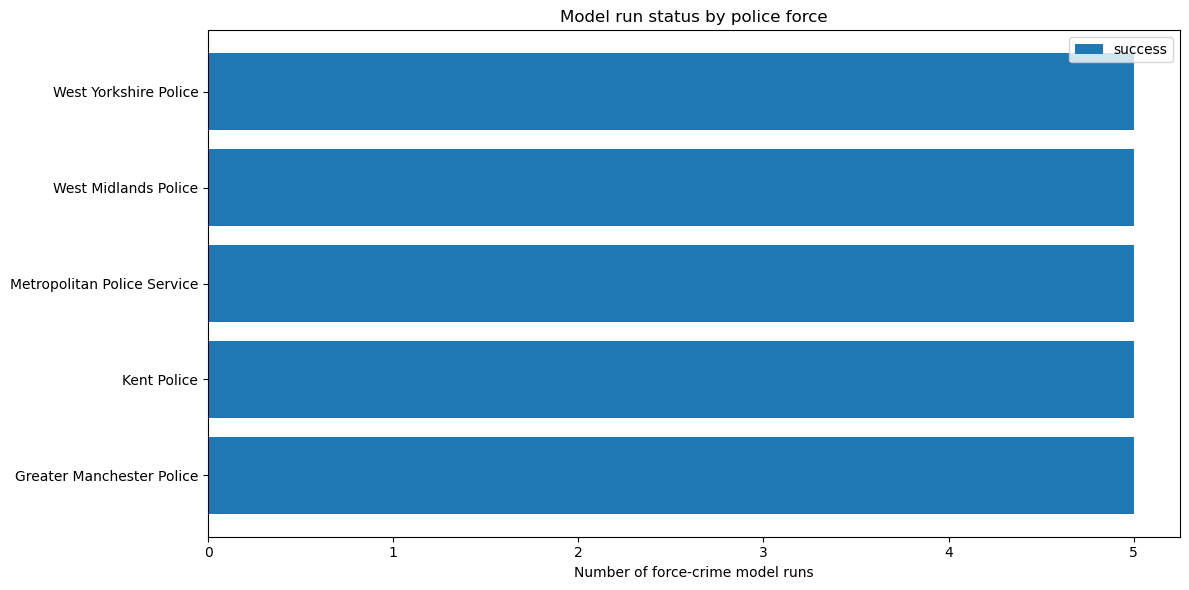

In [16]:
if len(summary) > 0:
    status_counts = (
        summary.groupby(["police_force", "model_status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    status_counts["total"] = status_counts.drop(columns=["police_force"]).sum(axis=1)
    status_counts = status_counts.sort_values("total", ascending=True)

    plt.figure(figsize=(12, max(6, len(status_counts) * 0.25)))
    if "success" in status_counts.columns:
        plt.barh(status_counts["police_force"], status_counts["success"], label="success")
    if "failed" in status_counts.columns:
        left = status_counts["success"] if "success" in status_counts.columns else 0
        plt.barh(status_counts["police_force"], status_counts["failed"], left=left, label="failed")
    plt.xlabel("Number of force-crime model runs")
    plt.title("Model run status by police force")
    plt.legend()
    plt.tight_layout()
    plt.show()


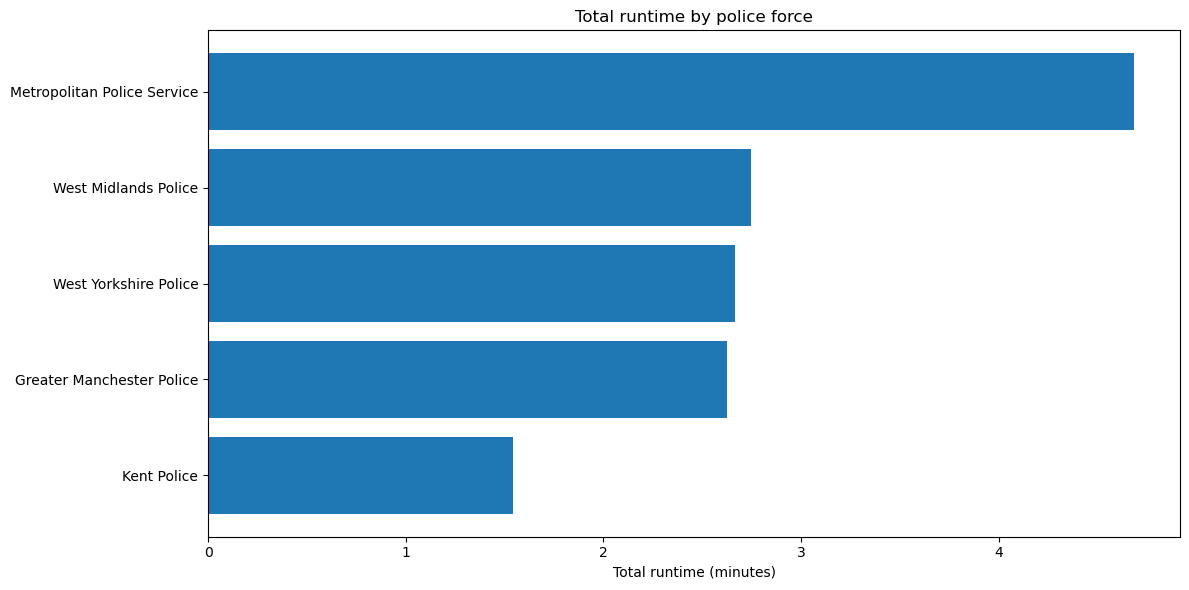

,police_force,total_runtime_seconds,mean_runtime_seconds,n_runs
2,Metropolitan Police Service,281.039200,56.207840,5
3,West Midlands Police,164.968274,32.993655,5
4,West Yorkshire Police,159.969825,31.993965,5
0,Greater Manchester Police,157.530716,31.506143,5
1,Kent Police,92.456358,18.491272,5


In [17]:
if len(successful) > 0:
    runtime_by_force = (
        successful.groupby("police_force", as_index=False)
        .agg(
            total_runtime_seconds=("runtime_seconds", "sum"),
            mean_runtime_seconds=("runtime_seconds", "mean"),
            n_runs=("crime_type", "count"),
        )
        .sort_values("total_runtime_seconds", ascending=True)
    )

    plt.figure(figsize=(12, max(6, len(runtime_by_force) * 0.25)))
    plt.barh(runtime_by_force["police_force"], runtime_by_force["total_runtime_seconds"] / 60)
    plt.xlabel("Total runtime (minutes)")
    plt.title("Total runtime by police force")
    plt.tight_layout()
    plt.show()

    display(runtime_by_force.sort_values("total_runtime_seconds", ascending=False).head(15))


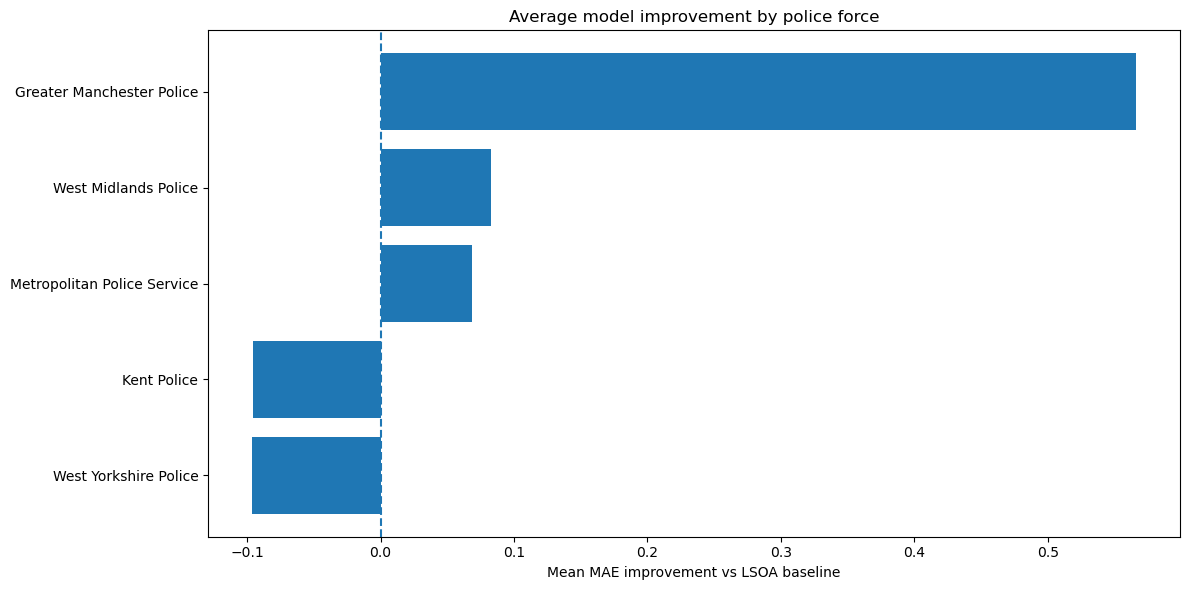

,police_force,mean_baseline_mae,mean_model_mae,mean_mae_improvement,pct_model_wins,n_runs
0,Greater Manchester Police,4.179542,3.613510,0.566032,1.0,5
3,West Midlands Police,1.603556,1.521062,0.082493,0.8,5
2,Metropolitan Police Service,1.821542,1.753039,0.068503,0.8,5
1,Kent Police,1.445375,1.541044,-0.095669,0.2,5
4,West Yorkshire Police,1.783194,1.879307,-0.096113,0.4,5


In [18]:
if len(successful) > 0:
    perf_by_force = (
        successful.groupby("police_force", as_index=False)
        .agg(
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_model_mae=("model_mae", "mean"),
            mean_mae_improvement=("mae_improvement_vs_baseline", "mean"),
            pct_model_wins=("winner_mae", lambda s: (s == "Bayesian NB adjacency").mean()),
            n_runs=("crime_type", "count"),
        )
        .sort_values("mean_mae_improvement", ascending=True)
    )

    plt.figure(figsize=(12, max(6, len(perf_by_force) * 0.25)))
    plt.barh(perf_by_force["police_force"], perf_by_force["mean_mae_improvement"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Mean MAE improvement vs LSOA baseline")
    plt.title("Average model improvement by police force")
    plt.tight_layout()
    plt.show()

    display(perf_by_force.sort_values("mean_mae_improvement", ascending=False).head(15))


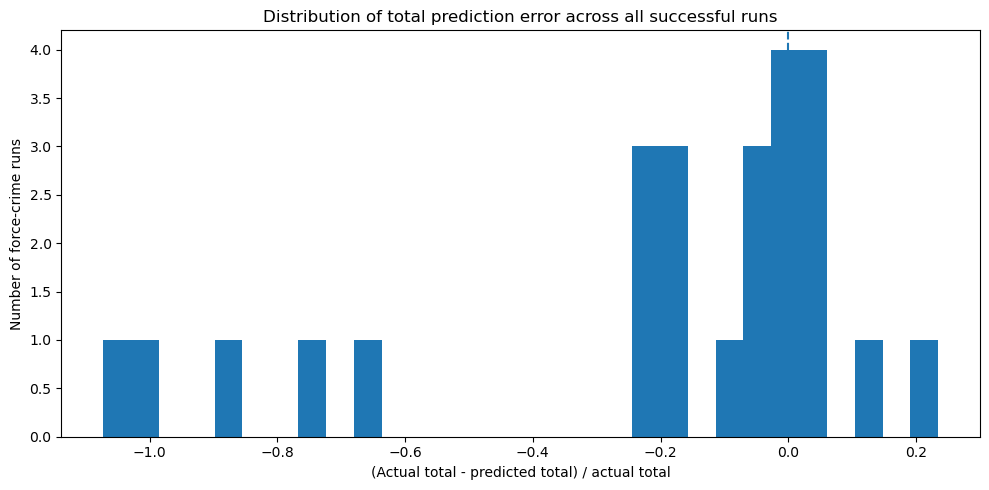

,police_force,crime_type,model_total_pct_error,model_abs_total_pct_error,model_mae,baseline_mae,winner_mae
9,Greater Manchester Police,Burglary,-1.072880,1.072880,2.515336,2.742847,Bayesian NB adjacency
5,Greater Manchester Police,Violence and sexual offences,-1.002640,1.002640,5.500478,5.706319,Bayesian NB adjacency
7,Greater Manchester Police,Public order,-0.867674,0.867674,3.300976,4.176111,Bayesian NB adjacency
8,Greater Manchester Police,Criminal damage and arson,-0.751812,0.751812,2.665286,3.255764,Bayesian NB adjacency
6,Greater Manchester Police,Anti-social behaviour,-0.644476,0.644476,4.085472,5.016667,Bayesian NB adjacency
18,West Midlands Police,Burglary,-0.243422,0.243422,1.492422,1.411111,LSOA mean baseline
21,Kent Police,Anti-social behaviour,0.234886,0.234886,1.925081,1.716181,LSOA mean baseline
14,West Yorkshire Police,Public order,-0.214842,0.214842,1.826519,1.634861,LSOA mean baseline
24,Kent Police,Public order,-0.208553,0.208553,1.427551,1.214931,LSOA mean baseline
13,West Yorkshire Police,Burglary,-0.181403,0.181403,1.603406,1.564514,LSOA mean baseline


In [19]:
if len(successful) > 0:
    plt.figure(figsize=(10, 5))
    plt.hist(successful["model_total_pct_error"].dropna(), bins=30)
    plt.axvline(0, linestyle="--")
    plt.xlabel("(Actual total - predicted total) / actual total")
    plt.ylabel("Number of force-crime runs")
    plt.title("Distribution of total prediction error across all successful runs")
    plt.tight_layout()
    plt.show()

    display(
        successful[
            [
                "police_force",
                "crime_type",
                "model_total_pct_error",
                "model_abs_total_pct_error",
                "model_mae",
                "baseline_mae",
                "winner_mae",
            ]
        ]
        .sort_values("model_abs_total_pct_error", ascending=False)
        .head(20)
    )


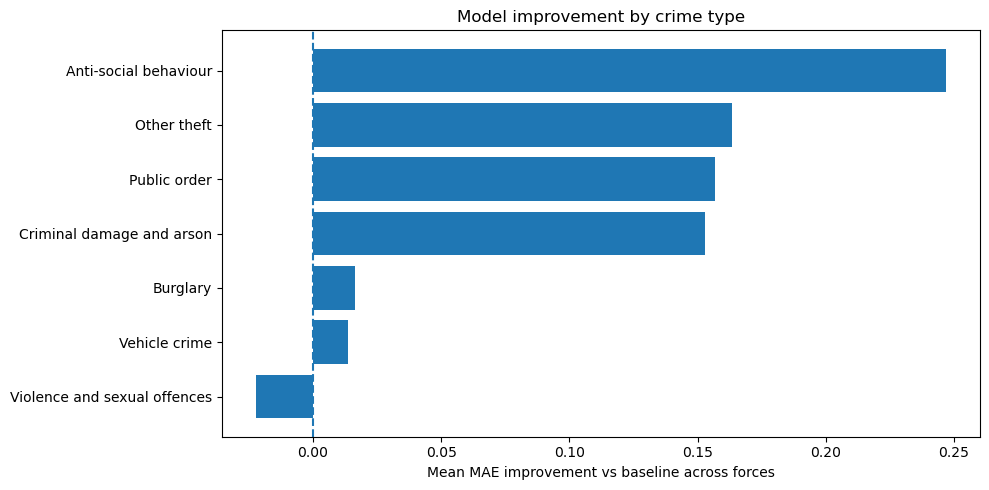

,crime_type,mean_baseline_mae,mean_model_mae,mean_mae_improvement,pct_model_wins,n_forces
0,Anti-social behaviour,2.439431,2.192715,0.246715,0.800000,5
3,Other theft,1.713333,1.549820,0.163513,1.000000,2
4,Public order,2.341968,2.185016,0.156952,0.333333,3
2,Criminal damage and arson,1.870781,1.717726,0.153055,0.750000,4
1,Burglary,1.807639,1.791266,0.016373,0.250000,4
5,Vehicle crime,1.782500,1.768725,0.013775,1.000000,2
6,Violence and sexual offences,2.647528,2.669625,-0.022097,0.600000,5


In [20]:
if len(successful) > 0:
    perf_by_crime = (
        successful.groupby("crime_type", as_index=False)
        .agg(
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_model_mae=("model_mae", "mean"),
            mean_mae_improvement=("mae_improvement_vs_baseline", "mean"),
            pct_model_wins=("winner_mae", lambda s: (s == "Bayesian NB adjacency").mean()),
            n_forces=("police_force", "nunique"),
        )
        .sort_values("mean_mae_improvement", ascending=True)
    )

    plt.figure(figsize=(10, max(5, len(perf_by_crime) * 0.35)))
    plt.barh(perf_by_crime["crime_type"], perf_by_crime["mean_mae_improvement"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Mean MAE improvement vs baseline across forces")
    plt.title("Model improvement by crime type")
    plt.tight_layout()
    plt.show()

    display(perf_by_crime.sort_values("mean_mae_improvement", ascending=False))


In [21]:
if not dashboard_all.empty:
    display(dashboard_all.head(10))
    print("Dashboard rows:", len(dashboard_all))
    print("Dashboard columns:", dashboard_all.columns.tolist())
    print("Forces:", dashboard_all["police_force"].nunique())
    print("Crime types:", dashboard_all["crime_type"].nunique())
else:
    print("No dashboard predictions were generated.")


,model_source,police_force,lsoa_code,lsoa_name,month,crime_type,observed_count,predicted_count,lower_ci,upper_ci,baseline_predicted_count,neighbour_prev_month_count,neighbour_prev_month_scaled,prev_month_count,log_offset
0,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-01-01,Violence and sexual offences,7,6.613333,3.0,11.0,6.5,10.0,0.420658,3.0,0.0
1,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-02-01,Violence and sexual offences,5,6.435000,3.0,11.0,6.5,7.8,-0.264014,7.0,0.0
2,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-03-01,Violence and sexual offences,8,6.600000,3.0,11.0,6.5,8.6,-0.015042,5.0,0.0
3,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-04-01,Violence and sexual offences,7,6.243333,2.0,11.0,6.5,9.4,0.233930,8.0,0.0
4,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-05-01,Violence and sexual offences,7,6.835000,3.0,11.0,6.5,9.0,0.109444,7.0,0.0
5,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-06-01,Violence and sexual offences,7,6.970000,3.0,12.0,6.5,9.4,0.233930,7.0,0.0
6,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-07-01,Violence and sexual offences,7,6.973333,3.0,12.0,6.5,7.4,-0.388499,7.0,0.0
7,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-08-01,Violence and sexual offences,7,6.535000,2.0,12.0,6.5,10.2,0.482901,7.0,0.0
8,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-09-01,Violence and sexual offences,8,6.705000,3.0,11.0,6.5,9.2,0.171687,7.0,0.0
9,adjacency_no_offset,Metropolitan Police Service,E01000105,Barking and Dagenham 014C,2019-10-01,Violence and sexual offences,8,6.738333,3.0,11.0,6.5,8.8,0.047201,8.0,0.0


Dashboard rows: 30000
Dashboard columns: ['model_source', 'police_force', 'lsoa_code', 'lsoa_name', 'month', 'crime_type', 'observed_count', 'predicted_count', 'lower_ci', 'upper_ci', 'baseline_predicted_count', 'neighbour_prev_month_count', 'neighbour_prev_month_scaled', 'prev_month_count', 'log_offset']
Forces: 5
Crime types: 7
